In [1]:
import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import os
import datetime
from statsmodels.api import OLS

# custom modules
import exploratory
import eia_ercot_data

Load hourly demand data. The data was originally retrieved from the EIA API using retrieve_ercot_data.py (requires an API key)

In [71]:
path_demand = 'data/demand_full_2025_11_30.csv'
df_demand_loader = exploratory.DemandData(path_demand=path_demand)
df_demand = df_demand_loader()

Confirm that there are no time gaps in the data

In [44]:
eia_ercot_data.time_gaps(df_demand['period_dt'])

minimum time between consecutive periods: 1.0 hours
maximimum time between consecutive periods: 1.0 hours


## Daily Demand

In [45]:
# daily data 
df_daily = (
    df_demand 
        .groupby('date', as_index = False) 
        .aggregate({'value':'sum'})
        .iloc[:-1]
)


End of data

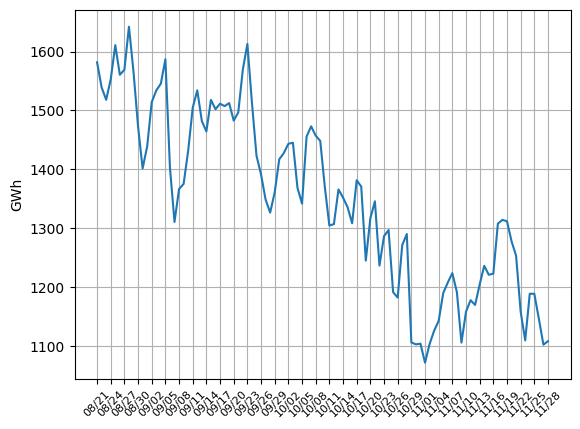

In [46]:
exploratory.plot_daily_end(df_daily)

Full daily series

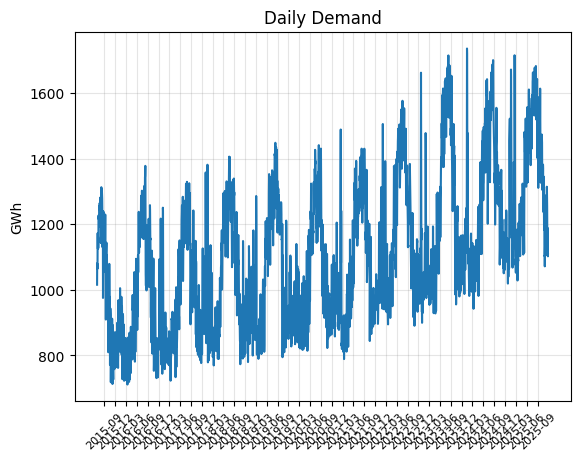

In [7]:
df_daily = (df_daily 
    .assign(first_of_month = lambda x: x['date'].apply(lambda x: datetime.date(x.year, 
                                                                               x.month, 
                                                                               1)))
    .assign(first_of_quarter = lambda x: x['date'].apply(lambda x: datetime.date(x.year, 
                                                                               3*((x.month - 1)//3 + 1), 
                                                                               1)))
)

df_daily = (df_daily
    .assign(month_label = np.where(df_daily['date'] == df_daily['first_of_month'], 
                                   df_daily['date'].apply(lambda x: x.strftime('%Y-%m')), 
                                   ''))
    .assign(quarter_label = np.where(df_daily['date'] == df_daily['first_of_quarter'], 
                                     df_daily['date'].apply(lambda x: x.strftime('%Y-%m')), 
                                    ''))
)

plt.plot(df_daily['date'],
         df_daily['value'] / 1000)
plt.xticks(ticks = df_daily['date'][df_daily['quarter_label']!=''], 
           labels = df_daily['quarter_label'][df_daily['quarter_label']!=''], 
           rotation = 45, 
           fontsize = 8)
plt.grid(color='gray',alpha=0.2)
plt.ylabel('GWh')
plt.title('Daily Demand')
plt.show()

## Monthly Data

In [28]:
df_monthly = (
    df_demand
        .assign(
            day_of_month = lambda df: df['period_dt'].dt.day, 
            month = lambda df: df['period_dt'].dt.month
        )
        .groupby(['year', 'month'], as_index=False) 
        .agg(value = ('value','sum'), 
             days = ('day_of_month', 'max'))
        .iloc[:-1]
        .assign(value = lambda df: df['value'] / df['days'])
)

Monthly series by year

Full monthly series

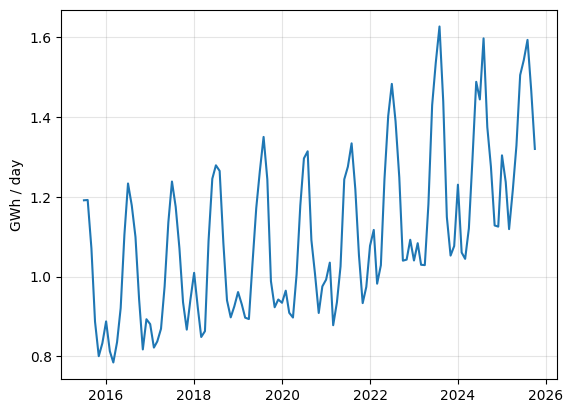

In [29]:
exploratory.plot_monthly_full(df_monthly)

## Intraday Seasonality

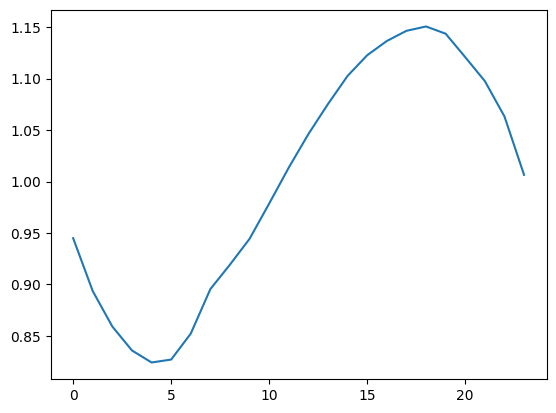

In [11]:
df_hour = (
    df_demand 
        .groupby('hour_of_day', as_index = False) 
        .agg({'value':'mean'})
)
df_hour['value'] = df_hour['value']/df_hour['value'].mean()

exploratory.plot_hourly(df_hour)

date      object
value    float64
year       int32
dtype: object

## When does the annual peak occur?

Date of maximum demand by year

In [ ]:
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily[df_daily['value'] == df_daily['value'].max()]['date'].values[0]
df_daily['year'] = pd.to_datetime(df_daily['date']).dt.year
df_max = pd.DataFrame([(year, exploratory.where_max(df)) for year, df in df_daily.groupby('year')])
df_max.columns = ['year', 'date_peak']
df_max

,year,day_peak
0,2015,2015-08-06
1,2016,2016-08-11
2,2017,2017-07-28
3,2018,2018-07-19
4,2019,2019-08-13
5,2020,2020-08-13
6,2021,2021-02-14
7,2022,2022-12-23
8,2023,2023-08-11
9,2024,2024-01-15


Date of maximum demand by year (excluding winter outliers)

In [59]:
#exbclude winter outliers
df_max = pd.DataFrame([(year, exploratory.where_max(df), pd.to_datetime(exploratory.where_max(df)).dayofyear) for year, df in \
              df_daily[df_daily['date'].dt.dayofyear.between(100,300)].groupby('year')])
df_max.columns = ['year', 'date_peak', 'day_nbr_peak']
df_max

,year,date_peak,day_nbr_peak
0,2015,2015-08-06,218
1,2016,2016-08-11,224
2,2017,2017-07-28,209
3,2018,2018-07-19,200
4,2019,2019-08-13,225
5,2020,2020-08-13,226
6,2021,2021-08-09,221
7,2022,2022-07-20,201
8,2023,2023-08-11,223
9,2024,2024-08-22,235
